In [19]:
# Cell 1: Setup & Imports
import sys
import os
from pathlib import Path

# Add project root to sys.path
project_root = str(Path().cwd().resolve())
if "notebooks" in project_root:
    project_root = str(Path().cwd().parent.resolve())
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import Core Modules
from core.data_fetcher.aligner import CrossSectionAligner
from backtest.evaluation import FactorEvaluator

# Import Factors
from factors.momentum.ts_momentum import TimeSeriesMomentum
from factors.momentum.reversal import ShortTermReversal
from factors.risk.volatility import HistoricalVolatility
from factors.volume.volume_shock import VolumeShock

In [20]:
# Cell 2: Load Processed Data
data_dict = {}
price_series_dict = {}

raw_dir = Path(project_root) / 'data' / 'raw'

print(f"Loading data from: {raw_dir}")

# Dynamically load all parquet files
for file_path in raw_dir.glob("*.parquet"):
    ticker = file_path.stem  # e.g., 'AAPL.US'
    
    try:
        df = pd.read_parquet(file_path)
        data_dict[ticker] = df
        
        # Extract close price for Alphalens forward return calculation
        if 'close' in df.columns:
            price_series_dict[ticker] = df['close']
    except Exception as e:
        print(f"Error loading {ticker}: {e}")

# Create wide DataFrame of price data (Dates x Tickers)
price_df = pd.DataFrame(price_series_dict)

print(f"Loaded {len(data_dict)} tickers into the universe.")
print(f"Price Matrix Shape: {price_df.shape}")

Loading data from: /Users/bytedance/workspace/factor_investment/data/raw
Loaded 31 tickers into the universe.
Price Matrix Shape: (4072, 31)


In [21]:
# Cell 3: Instantiate Factor Dictionary
# Define the tournament roster
factors_to_test = {
    'Momentum (252d)': TimeSeriesMomentum(lookback_period=252),
    'Reversal (5d)': ShortTermReversal(lookback_period=5),
    'Low Volatility (20d)': HistoricalVolatility(lookback_period=20),
    'Volume Shock (20d)': VolumeShock(ma_period=20)
}

print("Factors initialized for evaluation:")
for name in factors_to_test.keys():
    print(f"- {name}")

Factors initialized for evaluation:
- Momentum (252d)
- Reversal (5d)
- Low Volatility (20d)
- Volume Shock (20d)



Evaluating: Momentum (252d)
Calculating Momentum (252d)...
Aligning factor data...
Formatting for Alphalens...
Dropped 0.3% entries from factor data: 0.3% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Generating Tear Sheet for Momentum (252d)...
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.976029,0.368211,-0.182730,0.224206,26670,22.580645
2,-0.395276,0.597778,0.028301,0.101243,22860,19.354839
3,-0.238005,0.829948,0.128244,0.108150,22860,19.354839
4,-0.144821,1.008376,0.240627,0.123552,22860,19.354839
5,-0.014251,3.723632,0.504642,0.347065,22860,19.354839


Returns Analysis


,1D,5D,10D
Ann. alpha,0.009,0.013,0.011
beta,-0.039,-0.070,-0.040
Mean Period Wise Return Top Quantile (bps),0.361,-0.068,-0.119
Mean Period Wise Return Bottom Quantile (bps),0.716,0.553,0.490
Mean Period Wise Spread (bps),-0.355,-0.689,-0.671


Information Analysis


,1D,5D,10D
IC Mean,0.014,0.018,0.017
IC Std.,0.286,0.284,0.275
Risk-Adjusted IC,0.049,0.065,0.062
t-stat(IC),3.027,4.009,3.827
p-value(IC),0.002,0.000,0.000
IC Skew,-0.087,-0.092,-0.093
IC Kurtosis,-0.363,-0.327,-0.239


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.053,0.111,0.153
Quantile 2 Mean Turnover,0.139,0.280,0.369
Quantile 3 Mean Turnover,0.156,0.310,0.404
Quantile 4 Mean Turnover,0.142,0.286,0.377
Quantile 5 Mean Turnover,0.064,0.132,0.180


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.99,0.965,0.938


<Figure size 640x480 with 0 Axes>

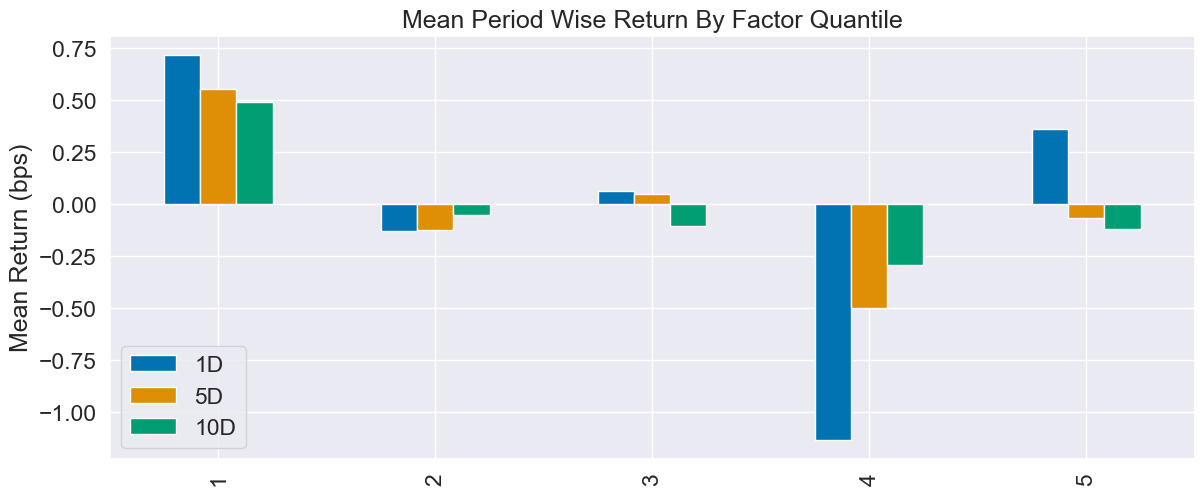

Finished evaluation for Momentum (252d).

Evaluating: Reversal (5d)
Calculating Reversal (5d)...
Aligning factor data...
Formatting for Alphalens...
Dropped 0.2% entries from factor data: 0.2% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Generating Tear Sheet for Reversal (5d)...
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.847815,0.128595,-0.037665,0.033926,28399,22.580645
2,-0.226331,0.154561,-0.013131,0.021536,24342,19.354839
3,-0.196779,0.180835,-0.001782,0.021175,24342,19.354839
4,-0.168576,0.225478,0.009938,0.022518,24342,19.354839
5,-0.121282,0.955190,0.035069,0.049432,24342,19.354839


Returns Analysis


,1D,5D,10D
Ann. alpha,0.009,0.007,0.011
beta,0.092,0.097,0.052
Mean Period Wise Return Top Quantile (bps),0.706,0.956,0.998
Mean Period Wise Return Bottom Quantile (bps),-0.574,-0.883,-0.506
Mean Period Wise Spread (bps),1.279,1.823,1.481


Information Analysis


,1D,5D,10D
IC Mean,0.011,0.013,0.012
IC Std.,0.261,0.247,0.244
Risk-Adjusted IC,0.043,0.051,0.050
t-stat(IC),2.722,3.229,3.165
p-value(IC),0.007,0.001,0.002
IC Skew,0.030,0.054,-0.018
IC Kurtosis,-0.172,-0.086,-0.145


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.341,0.765,0.768
Quantile 2 Mean Turnover,0.626,0.795,0.804
Quantile 3 Mean Turnover,0.658,0.794,0.797
Quantile 4 Mean Turnover,0.613,0.804,0.809
Quantile 5 Mean Turnover,0.362,0.797,0.796


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.747,-0.012,-0.009


<Figure size 640x480 with 0 Axes>

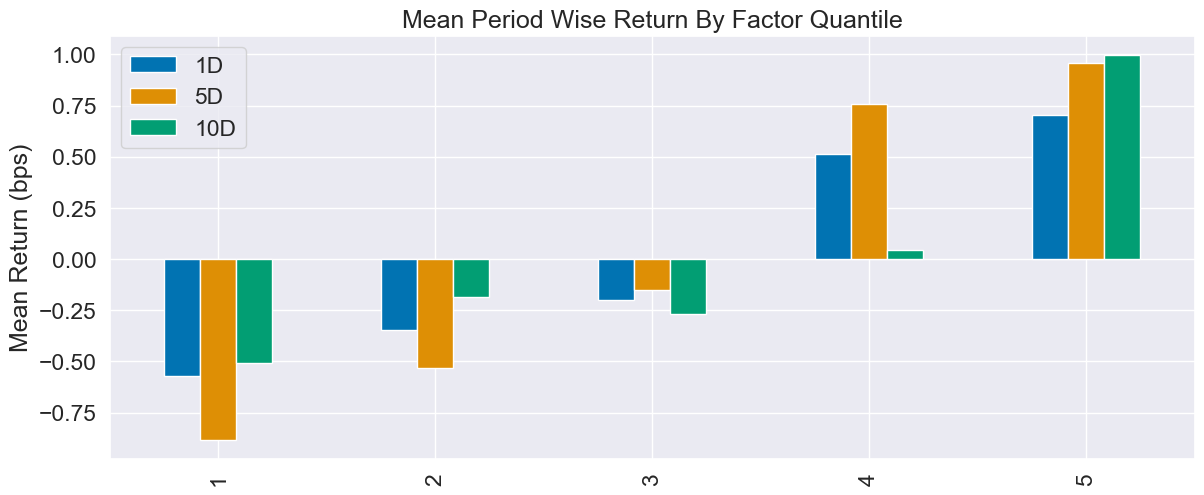

Finished evaluation for Reversal (5d).

Evaluating: Low Volatility (20d)
Calculating Low Volatility (20d)...
Aligning factor data...
Formatting for Alphalens...
Dropped 0.2% entries from factor data: 0.2% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Generating Tear Sheet for Low Volatility (20d)...
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-3.427980,-0.116906,-0.378778,0.275467,28294,22.580645
2,-1.294841,-0.100562,-0.253790,0.103392,24252,19.354839
3,-1.139281,-0.080217,-0.213455,0.089160,24252,19.354839
4,-1.020329,-0.066888,-0.179240,0.077198,24252,19.354839
5,-0.862450,-0.037825,-0.139425,0.063940,24252,19.354839


Returns Analysis


,1D,5D,10D
Ann. alpha,0.015,0.009,-0.002
beta,-0.313,-0.326,-0.290
Mean Period Wise Return Top Quantile (bps),-1.012,-1.671,-1.826
Mean Period Wise Return Bottom Quantile (bps),0.634,1.041,0.863
Mean Period Wise Spread (bps),-1.647,-2.617,-2.599


Information Analysis


,1D,5D,10D
IC Mean,-0.003,-0.022,-0.030
IC Std.,0.294,0.289,0.284
Risk-Adjusted IC,-0.010,-0.077,-0.106
t-stat(IC),-0.608,-4.919,-6.758
p-value(IC),0.543,0.000,0.000
IC Skew,0.030,0.111,0.165
IC Kurtosis,-0.371,-0.334,-0.437


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.088,0.236,0.351
Quantile 2 Mean Turnover,0.214,0.484,0.616
Quantile 3 Mean Turnover,0.245,0.519,0.651
Quantile 4 Mean Turnover,0.229,0.492,0.618
Quantile 5 Mean Turnover,0.111,0.274,0.388


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.966,0.851,0.724


<Figure size 640x480 with 0 Axes>

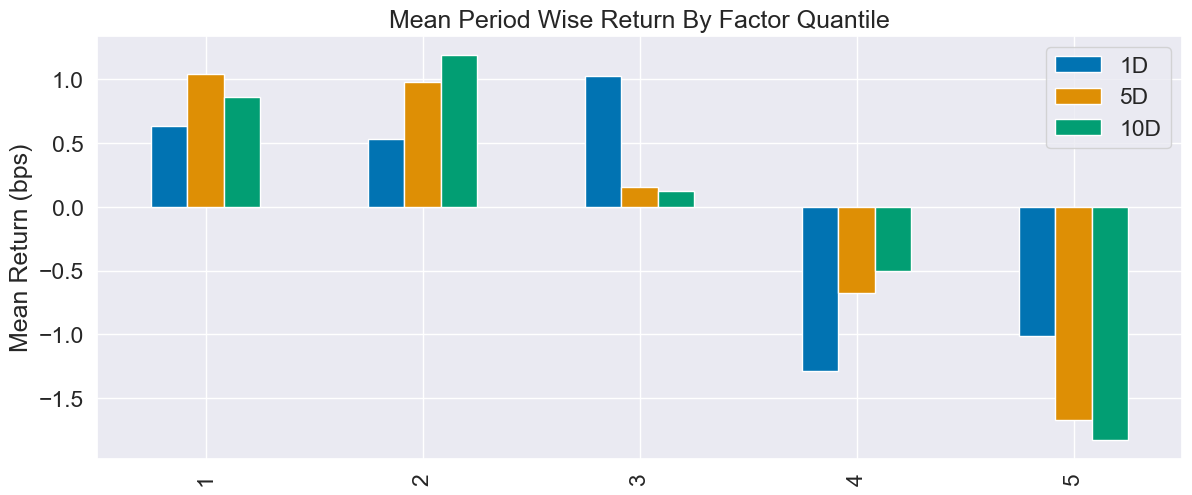

Finished evaluation for Low Volatility (20d).

Evaluating: Volume Shock (20d)
Calculating Volume Shock (20d)...
Aligning factor data...
Formatting for Alphalens...
Dropped 0.2% entries from factor data: 0.2% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Generating Tear Sheet for Volume Shock (20d)...
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,0.140580,2.118797,0.709074,0.173486,28301,22.580645
2,0.248049,2.419381,0.848759,0.192365,24258,19.354839
3,0.289226,2.501987,0.949760,0.217011,24258,19.354839
4,0.314640,3.061201,1.081207,0.253605,24258,19.354839
5,0.337406,11.233883,1.493792,0.608917,24258,19.354839


Returns Analysis


,1D,5D,10D
Ann. alpha,-0.074,-0.045,-0.034
beta,0.108,0.073,0.054
Mean Period Wise Return Top Quantile (bps),-0.885,-0.703,-0.883
Mean Period Wise Return Bottom Quantile (bps),0.066,0.728,0.490
Mean Period Wise Spread (bps),-0.950,-1.537,-1.463


Information Analysis


,1D,5D,10D
IC Mean,0.004,0.000,-0.003
IC Std.,0.197,0.197,0.192
Risk-Adjusted IC,0.019,0.002,-0.013
t-stat(IC),1.225,0.122,-0.843
p-value(IC),0.221,0.903,0.400
IC Skew,-0.024,-0.053,0.013
IC Kurtosis,-0.177,-0.238,-0.200


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.525,0.681,0.760
Quantile 2 Mean Turnover,0.755,0.799,0.806
Quantile 3 Mean Turnover,0.763,0.798,0.804
Quantile 4 Mean Turnover,0.749,0.781,0.798
Quantile 5 Mean Turnover,0.576,0.782,0.829


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.463,0.112,-0.032


<Figure size 640x480 with 0 Axes>

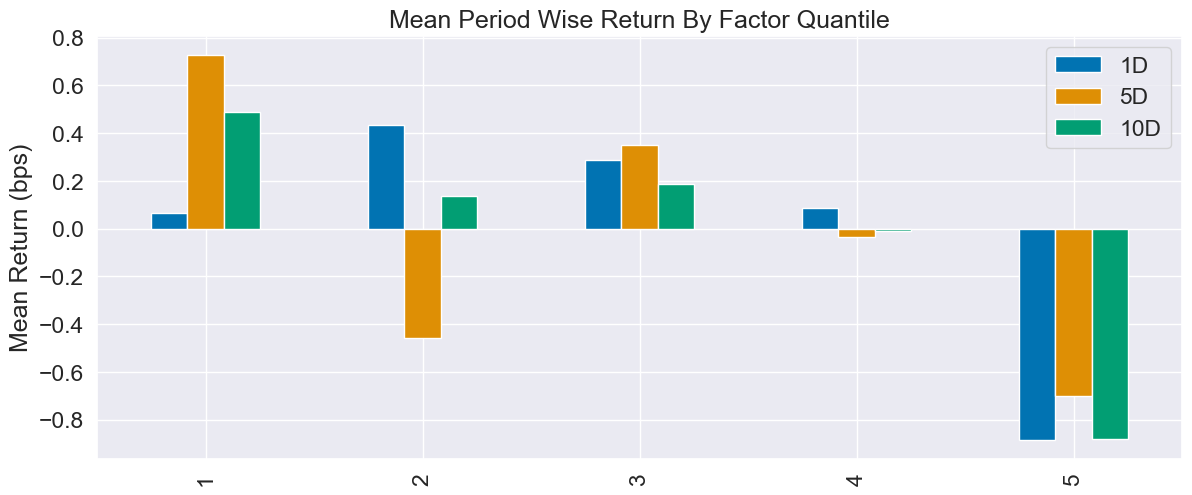

Finished evaluation for Volume Shock (20d).


In [22]:
# Cell 4: The Evaluation Loop (The Tournament)
aligner = CrossSectionAligner()
evaluator = FactorEvaluator()

for factor_name, factor_obj in factors_to_test.items():
    print(f"\n{'='*40}\nEvaluating: {factor_name}\n{'='*40}")
    
    # 1. Calculate Factor Values
    print(f"Calculating {factor_name}...")
    factor_values_dict = {}
    for ticker, df in data_dict.items():
        try:
            factor_values_dict[ticker] = factor_obj.compute(df)
        except Exception as e:
            print(f"Skipping {ticker} due to error: {e}")
            
    # 2. Align Factors (Convert to Long Format)
    print("Aligning factor data...")
    aligned_factor_df = aligner.align_factors(factor_values_dict)
    
    # 3. Format for Alphalens
    print("Formatting for Alphalens...")
    factor_data = evaluator.format_for_alphalens(
        aligned_factor=aligned_factor_df, 
        prices=price_df
    )
    
    # 4. Generate Tear Sheet
    print(f"Generating Tear Sheet for {factor_name}...")
    evaluator.generate_summary_tear_sheet(factor_data)
    
    print(f"Finished evaluation for {factor_name}.")

# 多因子

In [23]:
# 提取我们需要合成的因子 DataFrame (假设之前跑循环时你保留了计算结果)
# 为了演示，我们重新算一下最强的两个因子
factor_rev = ShortTermReversal(lookback_period=5)
factor_mom = TimeSeriesMomentum(lookback_period=252)

dict_for_combo = {
    'Reversal': aligner.align_factors({t: factor_rev.compute(d) for t, d in data_dict.items()}),
    'Momentum': aligner.align_factors({t: factor_mom.compute(d) for t, d in data_dict.items()})
}

Synthesizing Multi-Factor Portfolio...
Dropped 0.3% entries from factor data: 0.3% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-4.309095,0.003688,-0.905567,0.494951,26670,22.580645
2,-0.864898,0.317698,-0.268688,0.152110,22860,19.354839
3,-0.477173,0.501979,0.030615,0.132852,22860,19.354839
4,-0.137933,1.060190,0.343102,0.157589,22860,19.354839
5,0.036210,4.480337,0.951465,0.469304,22860,19.354839


Returns Analysis


,1D,5D,10D
Ann. alpha,0.006,0.001,0.010
beta,0.083,0.084,0.043
Mean Period Wise Return Top Quantile (bps),0.990,1.101,1.384
Mean Period Wise Return Bottom Quantile (bps),-1.031,-0.079,0.288
Mean Period Wise Spread (bps),2.021,1.142,1.046


Information Analysis


,1D,5D,10D
IC Mean,0.016,0.016,0.017
IC Std.,0.265,0.250,0.250
Risk-Adjusted IC,0.060,0.065,0.070
t-stat(IC),3.684,4.030,4.316
p-value(IC),0.000,0.000,0.000
IC Skew,0.045,0.092,0.016
IC Kurtosis,-0.143,-0.137,-0.175


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.322,0.716,0.719
Quantile 2 Mean Turnover,0.608,0.791,0.795
Quantile 3 Mean Turnover,0.638,0.789,0.795
Quantile 4 Mean Turnover,0.591,0.794,0.796
Quantile 5 Mean Turnover,0.343,0.759,0.761


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.768,0.084,0.079


<Figure size 640x480 with 0 Axes>

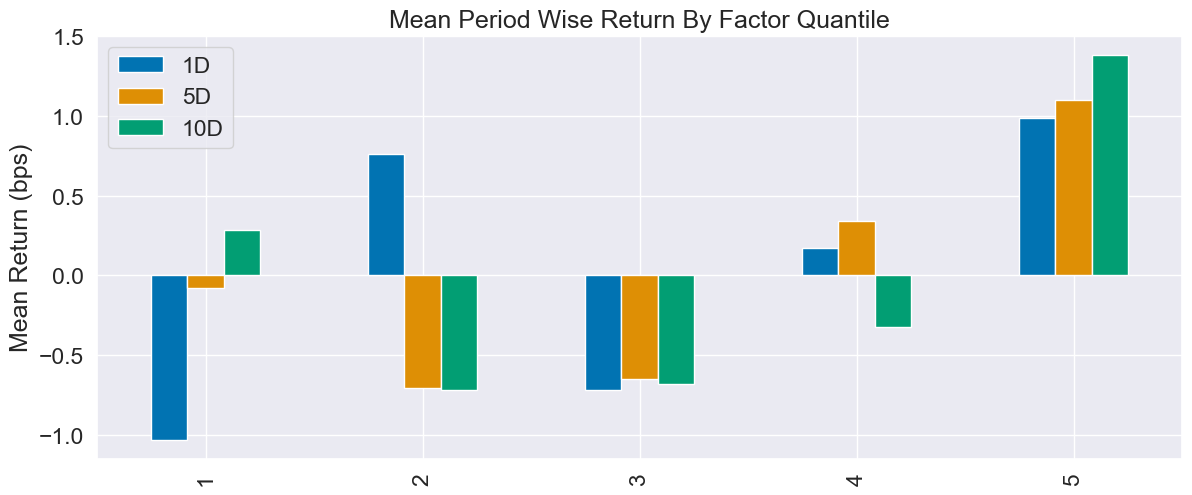

In [24]:
from portfolio.combiner import LinearFactorCombiner

# 实例化合成器
combiner = LinearFactorCombiner()

# 我们给冠军反转 70% 的权重，给长线动量 30% 的权重
weights = {'Reversal': 0.7, 'Momentum': 0.3}

print("Synthesizing Multi-Factor Portfolio...")
# 这步会在内部自动做截面 Z-Score 标准化并加权求和
combo_factor_df = combiner.combine(dict_for_combo, weights)

# 把这个终极超级因子扔进 Alphalens
clean_combo_data = evaluator.format_for_alphalens(combo_factor_df, price_df)
evaluator.generate_summary_tear_sheet(clean_combo_data)